### Assignment 1 (3 scores):

- Use the Numpy library only to construct the Linear Regression model.
- Train and Evaluate that Linear Regression model on the [Forest Fires](https://archive.ics.uci.edu/static/public/162/forest+fires.zip) dataset.

In [ ]:
import pandas as pd
from google.colab import files
files.upload()

In [167]:
df = pd.read_csv('forestfires.csv')
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [168]:
df.shape

(517, 13)

In [169]:
for col in df.columns:
  print(f'name: {col}')
  print(f'NaN: {df[col].isna().sum()}')
  print(f'null: {df[col].isnull().sum()}')
  print(f'type: {df[col].dtype}')
  print('-'*20)

name: X
NaN: 0
null: 0
type: int64
--------------------
name: Y
NaN: 0
null: 0
type: int64
--------------------
name: month
NaN: 0
null: 0
type: object
--------------------
name: day
NaN: 0
null: 0
type: object
--------------------
name: FFMC
NaN: 0
null: 0
type: float64
--------------------
name: DMC
NaN: 0
null: 0
type: float64
--------------------
name: DC
NaN: 0
null: 0
type: float64
--------------------
name: ISI
NaN: 0
null: 0
type: float64
--------------------
name: temp
NaN: 0
null: 0
type: float64
--------------------
name: RH
NaN: 0
null: 0
type: int64
--------------------
name: wind
NaN: 0
null: 0
type: float64
--------------------
name: rain
NaN: 0
null: 0
type: float64
--------------------
name: area
NaN: 0
null: 0
type: float64
--------------------


In [170]:
df['month'] = df['month'].map({'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul': 7, 'aug': 8, 'sep': 9, 'oct':10, 'nov': 11, 'dec': 12})
df['day'] = df['day'].map({'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5, 'sat': 6, 'sun': 7})
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,3,5,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [171]:
import numpy as np
class LinearRegression:
    def rmse(self, y_true, y_pred):
        delta = y_true - y_pred
        return np.sqrt(np.mean(delta**2))
    def fit(self, X, y):
        cov = np.matmul(X.T, X)
        int_cov = np.linalg.inv(cov)
        theta = int_cov @ X.T @ y
        self.theta = np.array(theta)
    def predict(self, X):
        return np.matmul(self.theta, X.T)
def train_lr(df):
    df.to_numpy()
    train_set = df.sample(frac=0.8, random_state=0)
    test_set = df.drop(train_set.index)
    X_train = train_set.drop('area', axis=1)
    y_train = train_set['area']
    X_test = test_set.drop('area', axis=1)
    y_test = test_set['area']
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    print("rmse =", lr.rmse(y_test, lr.predict(X_test)))

In [172]:
train_lr(df)

rmse = 35.21963542382532


statistical mechanism -> statistical ML -> probilistic ML

### Assignment 2 (3 scores):

- Standardize the data so that their mean is $0$ and their variance is $1$.
- Compare the results of Linear Regression model when being trained on the original and standardized data.

#### Data normalization

In [173]:
df_norm = df.copy()
df_norm = (df_norm - df_norm.mean()) / df_norm.std()
train_lr(df_norm)

rmse = 0.5509100190697831


The OLS estimator of a linear regression model has the form

$$
    \hat{\beta} = (X^T X)^{-1} X^T y
$$
where $X^T X \in \mathbb{R}^{K \times K}$ is called the normal matrix of the **Gram Matrix**.

Considering the convariance of $X$, we have

\begin{align}
    Cov(X)  & = \mathbb{E}[(X - \mathbb{E}[X])^2] \\
            & = \mathbb{E}[X^T X - 2 X^T\mathbb{E}[X] + \mathbb{E}[X]^T \mathbb{E}[X]] \\
            & = \mathbb{E}[X^T X] - 2 \mathbb{E}[X^T\mathbb{E}[X]] + \mathbb{E}[X]^T \mathbb{E}[X] \\
            & = \mathbb{E}[X^T X] - 2 \mathbb{E}[X]^T\mathbb{E}[X] + \mathbb{E}[X]^T \mathbb{E}[X] \\
            & = \mathbb{E}[X^T X] - \mathbb{E}[X]^T \mathbb{E}[X] \\
\end{align}

In case we have $\mathbb{E}[X] = 0$, then $X^T X = Cov(X)$. The normalization helps we to have the numerical stability of the input, theoretically leads to stable calculation when being applied to unseen data.

### Assignment 3 (2 scores):

- Perform feature engineering to remove columns that are linearly dependent (colinear) with other columns in the dataset.
- Evaluate the Linear Regression model when beeing trained on the original data and preprocessed data.

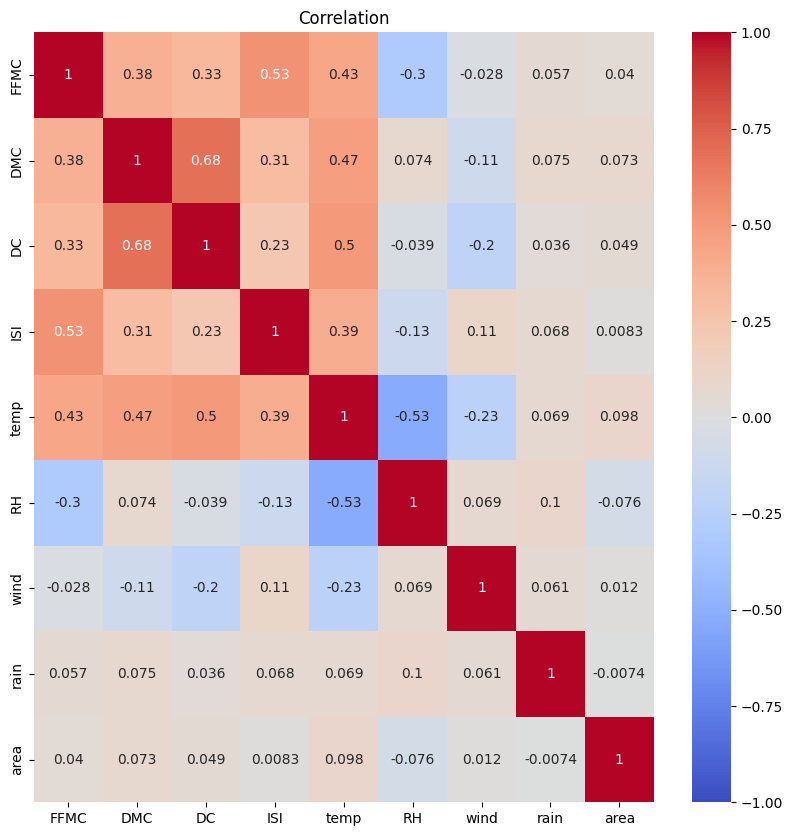

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns
columns_conti = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']
df_fe = df_norm[columns_conti]
plt.figure(figsize=(10, 10))
corr = df_fe.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation")
plt.show()

In [184]:
df_ft = df_norm.drop('ISI', axis=1) # Bỏ cột không tương quan với target
df_ft = df_norm.drop('rain', axis=1) # Bỏ cột không tương quan với target
df_ft.head()
train_lr(df_ft)

rmse = 0.5513544997508566


#### On the Problem of Colinearity

As stated previously, the OLS of the linear regression model is achieved by assuming that $rank(X) = K$ or $det(X) \ne 0$. So that removing columns in $X$ having colinearity with other columns is to ensure that assumption of the full rank condition of $X$. In the case $det(X) = 0$, then the **Moore-Penrose inverse** will be applied to determine the pseudo-inverse matrix of $X^T X$.

### Assignment 4 (2 scores):

- Implement the Linear Regression model using Machine Learning libraries (Scikit Learn or SKorch).
- Compare the results of Linear Regression model constructed manually and from Machine Learning libraries.

In [185]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
def train_lr_sklearn(df):
    df.to_numpy()
    train_set = df.sample(frac=0.8, random_state=10)
    test_set = df.drop(train_set.index)
    X_train = train_set.drop('area', axis=1)
    y_train = train_set['area']
    X_test = test_set.drop('area', axis=1)
    y_test = test_set['area']
    lr = linear_model.LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    print("rmse =", np.sqrt(mean_squared_error(y_test, y_pred)))

print("Begin")
train_lr_sklearn(df)
print("Manual")
train_lr_sklearn(df_norm)
print("Feature Engineering")
train_lr_sklearn(df_ft)
print("End")

Begin
rmse = 28.37565880401655
Manual
rmse = 0.44576693045440097
Feature Engineering
rmse = 0.4454776266563788
End
